In [1]:
import pandas as pd

In [2]:
csv_path=r"C:\Users\samya\PyCharmProject\Pneumonia-Detection\dataset\Patient_dataset_extract.csv"
# Load the full dataset
labels_df = pd.read_csv(csv_path)

In [3]:
details= pd.read_csv(r"C:\Users\samya\PyCharmProject\Pneumonia-Detection_dataset\data\stage_2_detailed_class_info.csv")
labels=pd.read_csv(r"C:\Users\samya\PyCharmProject\Pneumonia-Detection_dataset\data\stage_2_train_labels.csv")

In [4]:
# duplicates in details just have the same class so can be safely dropped
details = details.drop_duplicates('patientId').reset_index(drop=True)
labels_w_class = labels.merge(details, how='inner', on='patientId')

In [5]:
labels_w_class.head()
labels_w_class.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30227 entries, 0 to 30226
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   patientId  30227 non-null  object 
 1   x          9555 non-null   float64
 2   y          9555 non-null   float64
 3   width      9555 non-null   float64
 4   height     9555 non-null   float64
 5   Target     30227 non-null  int64  
 6   class      30227 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 1.6+ MB


In [6]:
# null values in x, y, width, height indicates that there is no pneumonia. Replacing null with 0
labels_w_class.fillna(0, inplace=True)
labels_w_class.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30227 entries, 0 to 30226
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   patientId  30227 non-null  object 
 1   x          30227 non-null  float64
 2   y          30227 non-null  float64
 3   width      30227 non-null  float64
 4   height     30227 non-null  float64
 5   Target     30227 non-null  int64  
 6   class      30227 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 1.6+ MB


In [7]:
labels_w_class['class'].value_counts()


class
No Lung Opacity / Not Normal    11821
Lung Opacity                     9555
Normal                           8851
Name: count, dtype: int64

In [8]:
new_df = labels_w_class.head(6000)
new_df.head()

,patientId,x,y,width,height,Target,class
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,0.0,0.0,0.0,0.0,0,No Lung Opacity / Not Normal
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,0.0,0.0,0.0,0.0,0,No Lung Opacity / Not Normal
2,00322d4d-1c29-4943-afc9-b6754be640eb,0.0,0.0,0.0,0.0,0,No Lung Opacity / Not Normal
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,0.0,0.0,0.0,0.0,0,Normal
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1,Lung Opacity


In [9]:
df = labels_w_class.copy()

In [10]:
from sklearn.model_selection import train_test_split


class_train, class_val = train_test_split(new_df, test_size=0.20, random_state=42, stratify=new_df['class'])
class_train_full, class_val_full = train_test_split(df, test_size=0.20, random_state=42, stratify=df['class'])

In [11]:
IMAGE_SIZE = 1024
ADJUSTED_IMAGE_SIZE=128
# MASK_IMAGE_SIZE = 14
# FACTOR = MASK_IMAGE_SIZE/IMAGE_SIZE
FACTOR = ADJUSTED_IMAGE_SIZE/IMAGE_SIZE

In [12]:
import os
import gc
import cv2
import pydicom
import numpy as np
from PIL import Image
from tensorflow.keras.applications.imagenet_utils import preprocess_input

# Path to training images
train_images_dir = r"C:\Users\samya\PyCharmProject\Pneumonia-Detection_dataset\data\stage_2_train_images"

def create_mask(datafm, labels_w_class, image_size, factor, save_mask_dir=None):
    X = []
    y = []
    masks = np.zeros((len(datafm), image_size, image_size), dtype=np.uint8)

    for index, patient_id in enumerate(datafm['patientId'].values):
        image_path = os.path.join(train_images_dir, patient_id + ".dcm")

        if not os.path.exists(image_path):
            print(f"Missing file: {image_path}")
            continue

        # Load and preprocess DICOM image
        img_dcm = pydicom.dcmread(image_path)
        img = img_dcm.pixel_array
        img = cv2.resize(img, (image_size, image_size), interpolation=cv2.INTER_NEAREST)
        img = Image.fromarray(img).convert('RGB')
        img = preprocess_input(np.array(img, dtype=np.float32))
        X.append(img)

        # Create binary mask
        rows = labels_w_class[labels_w_class['patientId'] == patient_id]
        y.append(rows['Target'].values[0])

        for _, row in rows.iterrows():
            x1 = int(row['x'] * factor)
            y1 = int(row['y'] * factor)
            x2 = int((row['x'] + row['width']) * factor)
            y2 = int((row['y'] + row['height']) * factor)
            masks[index, y1:y2, x1:x2] = 1

        # Optionally save mask as PNG
        if save_mask_dir:
            os.makedirs(save_mask_dir, exist_ok=True)
            mask_path = os.path.join(save_mask_dir, f"{patient_id}_mask.png")
            mask_uint8 = (masks[index] * 255).astype(np.uint8)
            Image.fromarray(mask_uint8).save(mask_path)

    # Final arrays
    X = np.array(X)
    y = np.array(y)
    train_masks_input = np.expand_dims(masks, axis=3)  # shape: (N, H, W, 1)

    gc.collect()
    return X, y, train_masks_input, masks


In [13]:
import numpy as np

In [14]:
import pydicom

In [15]:
X_train, y_tr_target, y_train, mask_train = create_mask(
    class_train,
    labels_w_class=labels_w_class,
    image_size=ADJUSTED_IMAGE_SIZE,
    factor=FACTOR
)

X_val, y_val_target, y_val, mask_val = create_mask(
    class_val,
    labels_w_class=labels_w_class,
    image_size=ADJUSTED_IMAGE_SIZE,
    factor=FACTOR
)

KeyboardInterrupt: 

In [ ]:
X_train.shape, y_tr_target.shape, y_train.shape, X_val.shape, y_val_target.shape, y_val.shape

((4800, 128, 128, 3),
 (4800,),
 (4800, 128, 128, 1),
 (1200, 128, 128, 3),
 (1200,),
 (1200, 128, 128, 1))

In [ ]:
import tensorflow as tf 

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE


In [ ]:
train = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(16).prefetch(buffer_size=AUTOTUNE)
val = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(32).prefetch(buffer_size=AUTOTUNE)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-122.68..143.061].


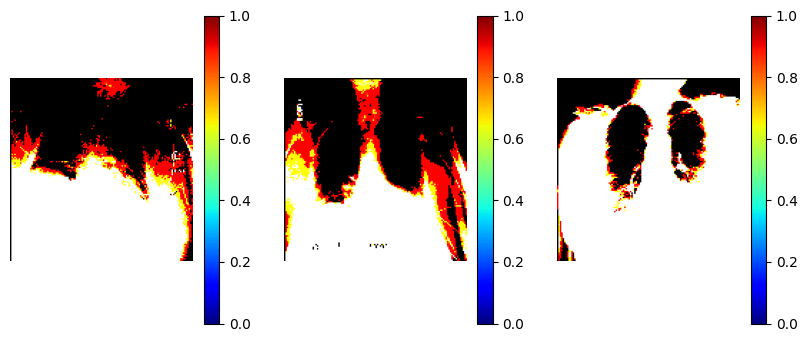

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
for i in range(1,4):
    plt.subplot(1,3,i)
    img = X_train[i]
    plt.imshow(img, cmap='jet')
    plt.colorbar()
    plt.axis('off')
plt.show() 

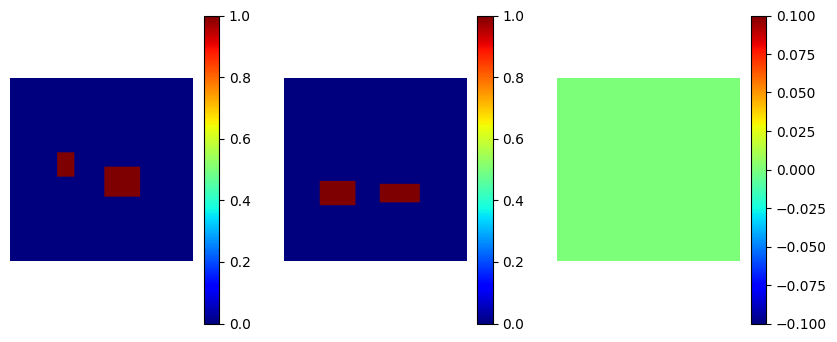

In [ ]:
plt.figure(figsize=(10,4))
for i in range(1,4):
    plt.subplot(1,3,i)
    img = mask_train[i]
    plt.imshow(img, cmap='jet')
    plt.colorbar()
    plt.axis('off')
plt.show() 

In [ ]:
!pip install segmentation-models

In [ ]:
import os
os.environ["SM_FRAMEWORK"] = "tf.keras"
import segmentation_models as sm

Segmentation Models: using `tf.keras` framework.


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Conv2DTranspose, concatenate
from tensorflow.keras.optimizers import Adam

def build_resnet50_unet(input_shape=(128, 128, 3), n=1, lr=1e-4, loss='binary_crossentropy', metrics=['accuracy']):
    inputs = Input(shape=input_shape)
    base_model = ResNet50(include_top=False, weights='imagenet', input_tensor=inputs)

    # Encoder skip connections
    skip1 = base_model.get_layer("conv1_relu").output     # 128x128
    skip2 = base_model.get_layer("conv2_block3_out").output  # 64x64
    skip3 = base_model.get_layer("conv3_block4_out").output  # 32x32
    skip4 = base_model.get_layer("conv4_block6_out").output  # 16x16

    bottleneck = base_model.get_layer("conv5_block3_out").output  # 8x8

    # Decoder
    up1 = Conv2DTranspose(512, 3, strides=2, padding='same')(bottleneck)
    up1 = concatenate([up1, skip4])
    up1 = Conv2D(512, 3, activation='relu', padding='same')(up1)

    up2 = Conv2DTranspose(256, 3, strides=2, padding='same')(up1)
    up2 = concatenate([up2, skip3])
    up2 = Conv2D(256, 3, activation='relu', padding='same')(up2)

    up3 = Conv2DTranspose(128, 3, strides=2, padding='same')(up2)
    up3 = concatenate([up3, skip2])
    up3 = Conv2D(128, 3, activation='relu', padding='same')(up3)

    up4 = Conv2DTranspose(64, 3, strides=2, padding='same')(up3)
    up4 = concatenate([up4, skip1])
    up4 = Conv2D(64, 3, activation='relu', padding='same')(up4)

    up5 = Conv2DTranspose(32, 3, strides=2, padding='same')(up4)
    up5 = Conv2D(32, 3, activation='relu', padding='same')(up5)

    output = Conv2D(n, 1, activation='sigmoid')(up5)

    model = Model(inputs, output)
    model.compile(optimizer=Adam(learning_rate=lr), loss=loss, metrics=metrics)
    return model


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Conv2DTranspose, concatenate
from tensorflow.keras.optimizers import Adam

def build_mobilenetv2_unet(input_shape=(128, 128, 3), n=1, lr=1e-4, loss='binary_crossentropy', metrics=['accuracy']):
    inputs = Input(shape=input_shape)
    base_model = MobileNetV2(include_top=False, weights='imagenet', input_tensor=inputs)

    # Encoder skip connections (MobileNetV2 has fewer useful blocks)
    skip1 = base_model.get_layer("block_1_expand_relu").output   # 128x128
    skip2 = base_model.get_layer("block_3_expand_relu").output   # 64x64
    skip3 = base_model.get_layer("block_6_expand_relu").output   # 32x32
    skip4 = base_model.get_layer("block_13_expand_relu").output  # 16x16

    bottleneck = base_model.get_layer("block_16_project").output  # 8x8

    # Decoder
    up1 = Conv2DTranspose(512, 3, strides=2, padding='same')(bottleneck)
    up1 = concatenate([up1, skip4])
    up1 = Conv2D(512, 3, activation='relu', padding='same')(up1)

    up2 = Conv2DTranspose(256, 3, strides=2, padding='same')(up1)
    up2 = concatenate([up2, skip3])
    up2 = Conv2D(256, 3, activation='relu', padding='same')(up2)

    up3 = Conv2DTranspose(128, 3, strides=2, padding='same')(up2)
    up3 = concatenate([up3, skip2])
    up3 = Conv2D(128, 3, activation='relu', padding='same')(up3)

    up4 = Conv2DTranspose(64, 3, strides=2, padding='same')(up3)
    up4 = concatenate([up4, skip1])
    up4 = Conv2D(64, 3, activation='relu', padding='same')(up4)

    up5 = Conv2DTranspose(32, 3, strides=2, padding='same')(up4)
    up5 = Conv2D(32, 3, activation='relu', padding='same')(up5)

    output = Conv2D(n, 1, activation='sigmoid')(up5)

    model = Model(inputs, output)
    model.compile(optimizer=Adam(learning_rate=lr), loss=loss, metrics=metrics)
    return model


In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Conv2DTranspose, concatenate, UpSampling2D
from tensorflow.keras.optimizers import Adam

def build_densenet121_unet(input_shape=(128, 128, 3), n=1, lr=1e-4, loss='binary_crossentropy', metrics=['accuracy']):
    # Input layer
    inputs = Input(shape=input_shape)

    # Load DenseNet121 as encoder (without top classifier layers)
    base_model = DenseNet121(include_top=False, weights='imagenet', input_tensor=inputs)

    # Encoder layers (skip connections)
    skip1 = base_model.get_layer("conv1_relu").output     # 128x128
    skip2 = base_model.get_layer("pool2_relu").output     # 64x64
    skip3 = base_model.get_layer("pool3_relu").output     # 32x32
    skip4 = base_model.get_layer("pool4_relu").output     # 16x16

    # Bottleneck
    bottleneck = base_model.output                        # 8x8

    # Decoder path (U-Net style upsampling + concatenation)
    up1 = Conv2DTranspose(512, (3, 3), strides=(2, 2), padding='same')(bottleneck)  # 16x16
    up1 = concatenate([up1, skip4])
    up1 = Conv2D(512, 3, activation='relu', padding='same')(up1)

    up2 = Conv2DTranspose(256, (3, 3), strides=(2, 2), padding='same')(up1)  # 32x32
    up2 = concatenate([up2, skip3])
    up2 = Conv2D(256, 3, activation='relu', padding='same')(up2)

    up3 = Conv2DTranspose(128, (3, 3), strides=(2, 2), padding='same')(up2)  # 64x64
    up3 = concatenate([up3, skip2])
    up3 = Conv2D(128, 3, activation='relu', padding='same')(up3)

    up4 = Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same')(up3)  # 128x128
    up4 = concatenate([up4, skip1])
    up4 = Conv2D(64, 3, activation='relu', padding='same')(up4)

    up5 = Conv2DTranspose(32, (3, 3), strides=(2, 2), padding='same')(up4)  # 256x256
    up5 = Conv2D(32, 3, activation='relu', padding='same')(up5)

    # Final layer (output)
    output = Conv2D(n, 1, activation='sigmoid')(up5)

    # Create and compile model
    model = Model(inputs, output)
    model.compile(optimizer=Adam(learning_rate=lr), loss=loss, metrics=metrics)
    return model


In [ ]:
import tensorflow as tf
METRICS = [
    'accuracy',
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.AUC(name='AUC'),
    tf.keras.metrics.TruePositives(name='tp'),
    tf.keras.metrics.TrueNegatives(name='tn'),
    tf.keras.metrics.FalsePositives(name='fp'),
    tf.keras.metrics.FalseNegatives(name='fn'),
    tf.keras.metrics.SpecificityAtSensitivity(0.9, name='specificity_at_sens_90'),
    tf.keras.metrics.SensitivityAtSpecificity(0.9, name='sensitivity_at_spec_90'),
]

In [ ]:
import tensorflow as tf

# Flexible Exponential Decay Function
def get_exponential_decay_fn(lr_initial=0.01, decay_steps=20, decay_rate=0.1):
    """
    Returns a learning rate function using exponential decay.
    """
    return lambda epoch: lr_initial * decay_rate ** (epoch / decay_steps)

# Returns a LearningRateScheduler callback with decay configuration
def get_lr_scheduler_cb(lr_initial=0.01, decay_steps=20, decay_rate=0.1):
    return tf.keras.callbacks.LearningRateScheduler(
        schedule=get_exponential_decay_fn(lr_initial, decay_steps, decay_rate),
        verbose=1
    )

# Returns a ModelCheckpoint callback that saves to a unique file
def get_model_checkpoint_cb(model_name):
    return tf.keras.callbacks.ModelCheckpoint(
        filepath=f"{model_name}.keras",
        save_best_only=True,
        monitor="val_loss",
        mode="min",
        verbose=1
    )

# Shared EarlyStopping callback
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    patience=5,
    restore_best_weights=True,
    monitor="val_loss",
    mode="min",
    verbose=1
)

In [ ]:
resnet_model = build_resnet50_unet(metrics=METRICS)
resnet_model.summary()
resnet_model.save("unet_resnet50.h5")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 43,966,305 (167.72 MB)

 Trainable params: 43,913,185 (167.52 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
callbacks = [
    get_lr_scheduler_cb(lr_initial=1e-4),
    get_model_checkpoint_cb("resnet50_unet_best"),
    early_stopping_cb
]

h1 = resnet_model.fit(
    train,
    validation_data=val,
    epochs=15,
    callbacks=callbacks
)


Epoch 1: LearningRateScheduler setting learning rate to 0.0001.
Epoch 1/15


300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - AUC: 0.7728 - accuracy: 0.9275 - fn: 1906422.6250 - fp: 507955.1562 - loss: 0.2178 - precision: 0.3354 - recall: 0.1498 - sensitivity_at_spec_90: 0.3918 - specificity_at_sens_90: 0.4900 - tn: 36530016.0000 - tp: 508284.7188
Epoch 1: val_loss improved from inf to 0.11724, saving model to resnet50_unet_best.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 1716s 5s/step - AUC: 0.7733 - accuracy: 0.9275 - fn: 1911060.7500 - fp: 509859.3750 - loss: 0.2176 - precision: 0.3362 - recall: 0.1503 - sensitivity_at_spec_90: 0.3928 - specificity_at_sens_90: 0.4908 - tn: 36650128.0000 - tp: 511831.5000 - val_AUC: 0.9493 - val_accuracy: 0.9557 - val_fn: 716253.0000 - val_fp: 154329.0000 - val_loss: 0.1172 - val_precision: 0.7462 - val_recall: 0.3878 - val_sensitivity_at_spec_90: 0.8827 - val_specificity_at_sens_90: 0.8900 - val_tn: 18336452.0000 - val_tp: 453765.0000 - learning_rate: 1.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 8.912509381337456e-05.

In [ ]:
mobilenet_model = build_mobilenetv2_unet()
mobilenet_model.summary()
mobilenet_model.save("unet_mobilenetv2.h5")

C:\Users\samya\AppData\Local\Temp\ipykernel_11408\1634888407.py:8: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(include_top=False, weights='imagenet', input_tensor=inputs)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 11,345,697 (43.28 MB)

 Trainable params: 11,314,785 (43.16 MB)

 Non-trainable params: 30,912 (120.75 KB)

In [ ]:
callbacks = [
    get_lr_scheduler_cb(lr_initial=1e-4),
    get_model_checkpoint_cb("mobilenet_unet_best"),
    early_stopping_cb
]

h2 = mobilenet_model.fit(
    train,
    validation_data=val,
    epochs=15,
    callbacks=callbacks
)

In [ ]:
densenet_model = build_densenet121_unet()
densenet_model.summary()
densenet_model.save("unet_densenet121.h5")

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 134, 134,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 32, 32,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 32, 32,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 32, 32,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 32, 32,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 32, 32,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 32, 32,    │     12,288 │ conv2_block2_0_r

 Total params: 22,697,505 (86.58 MB)

 Trainable params: 22,613,857 (86.27 MB)

 Non-trainable params: 83,648 (326.75 KB)

In [ ]:
callbacks = [
    get_lr_scheduler_cb(lr_initial=1e-4),
    get_model_checkpoint_cb("densenet_unet_best"),
    early_stopping_cb
]

h2 = densenet_model.fit(
    train,
    validation_data=val,
    epochs=15,
    callbacks=callbacks
)